Image to Text code
multimodal image captioning



preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

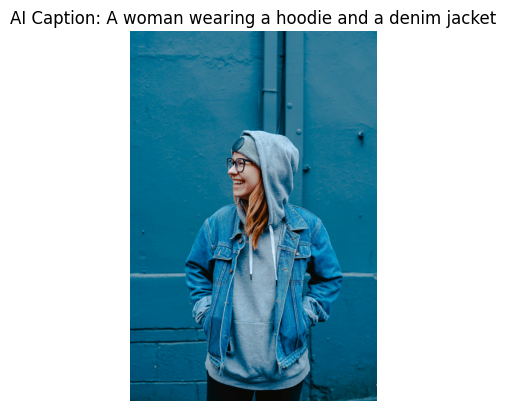


--- Multimodal Analysis ---
Generated Description: a woman wearing a hoodie and a denim jacket


In [5]:
# 1. Install necessary libraries
!pip install transformers pillow requests

import requests
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
import matplotlib.pyplot as plt

# 2. Load the Processor and Model
# The processor handles image resizing; the model handles the AI 'vision'
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# 3. Select an Image
# You can change this URL to any image you want to test
img_url = "https://images.unsplash.com/photo-1517841905240-472988babdf9"
raw_image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')

# 4. Process and Generate
# we convert the image into 'tensors' that the AI understands
inputs = processor(raw_image, return_tensors="pt")

# Generate the caption (max_new_tokens limits the length of the sentence)
out = model.generate(**inputs, max_new_tokens=50)
caption = processor.decode(out[0], skip_special_tokens=True)

# 5. Display the Output
plt.imshow(raw_image)
plt.axis("off")
plt.title(f"AI Caption: {caption.capitalize()}")
plt.show()

print(f"\n--- Multimodal Analysis ---")
print(f"Generated Description: {caption}")